Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (15996000, 13)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 407.0305 - mae: 12.7563 - val_loss: 7.8630 - val_mae: 2.0941
Epoch 2/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 10.4123 - mae: 2.4024 - val_loss: 0.3458 - val_mae: 0.4822
Epoch 3/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.3233 - mae: 1.9079 - val_loss: 0.0673 - val_mae: 0.1790
Epoch 4/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.5718 - mae: 1.7856 - val_loss: 0.0346 - val_mae: 0.1263
Epoch 5/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1403 - mae: 1.7111 - val_loss: 0.0952 - val_mae: 0.2314
Epoch 6/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7105 - mae: 1.6466 - val_loss: 0.0679 - val_mae: 0.1945
Epoch 7/10
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.5337 - mae: 1.6082 - val_loss: 0.0357 - val_mae: 0.1441
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
MAE: 0.1259023382332835
5215/5215 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


522/522 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 945.1819 
Epoch 2/8
522/522 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 596.7491
Epoch 3/8
522/522 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 434.9725
Epoch 4/8
522/522 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 364.0092
Epoch 5/8
522/522 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 339.6941
Epoch 6/8
522/522 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 333.8521
Epoch 7/8
522/522 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 332.9824
Epoch 8/8
522/522 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 332.9204
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━

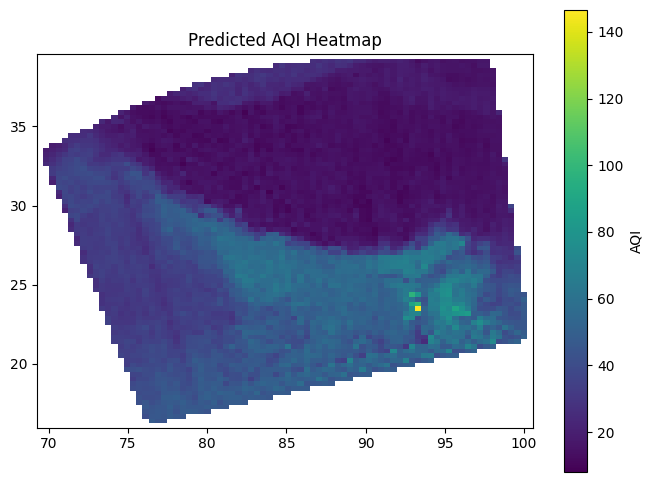

Models Saved to Drive


In [3]:
# =====================================
# ECOTHON FAST AQI PIPELINE
# Sentinel-5P → City AQI Forecast System
# =====================================

!pip install tensorflow scikit-learn joblib scipy

# =====================================
# 1. Imports
# =====================================

import pandas as pd
import numpy as np
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

from scipy.interpolate import griddata

import matplotlib.pyplot as plt

# =====================================
# 2. Mount Drive
# =====================================

from google.colab import drive
drive.mount('/content/drive')

# =====================================
# 3. Load Dataset
# =====================================

DATA_PATH = "/content/drive/MyDrive/sentinel-5p.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

# Reduce dataset for faster training
df = df.sample(min(len(df), 200000))

df = df.dropna()

# =====================================
# 4. Feature Engineering
# =====================================

features = ['carbonmonoxide_total_column','qa_value']
geo = ['latitude','longitude']

# Synthetic AQI
df["AQI"] = df['carbonmonoxide_total_column'] * 1000

# Pollution Source Estimation
def pollution_source(row):

    co = row['carbonmonoxide_total_column']

    if co > 0.05:
        return "Industrial"
    elif co > 0.03:
        return "Vehicle Emissions"
    else:
        return "Background"

df["Pollution_Source"] = df.apply(pollution_source, axis=1)

# =====================================
# 5. Scaling
# =====================================

X = df[features]
y = df["AQI"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================
# 6. Train/Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)

# =====================================
# 7. Fast AQI Prediction Model
# =====================================

model = Sequential([

    Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    Dense(32,activation='relu'),

    Dense(1)

])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model.fit(
    X_train,y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    callbacks=[early],
    verbose=1
)

# =====================================
# 8. Evaluate
# =====================================

pred = model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred))

# =====================================
# 9. Generate AQI Predictions
# =====================================

df["Predicted_AQI"] = model.predict(X_scaled)

# =====================================
# 10. LSTM 14-Day Forecast
# =====================================

series = df["AQI"].values

seq_len = 14

X_seq = []
y_seq = []

for i in range(len(series)-seq_len):

    X_seq.append(series[i:i+seq_len])
    y_seq.append(series[i+seq_len])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_seq = X_seq.reshape((X_seq.shape[0],X_seq.shape[1],1))

split = int(0.8*len(X_seq))

X_train_lstm = X_seq[:split]
X_test_lstm = X_seq[split:]

y_train_lstm = y_seq[:split]
y_test_lstm = y_seq[split:]

lstm = Sequential([

    LSTM(32,return_sequences=True,input_shape=(seq_len,1)),
    LSTM(16),

    Dense(1)

])

lstm.compile(
    optimizer='adam',
    loss='mse'
)

lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=8,
    batch_size=256
)

# =====================================
# 11. Forecast Next 14 Days
# =====================================

last_sequence = series[-seq_len:]

future = []

current = last_sequence.copy()

for i in range(14):

    pred = lstm.predict(current.reshape(1,seq_len,1))[0][0]

    future.append(pred)

    current = np.append(current[1:],pred)

print("Next 14 Day AQI Forecast")

print(future)

# =====================================
# 12. AQI Heatmap
# =====================================

points = df[['longitude','latitude']].values
values = df['Predicted_AQI'].values

grid_x, grid_y = np.mgrid[
    df.longitude.min():df.longitude.max():80j,
    df.latitude.min():df.latitude.max():80j
]

grid_z = griddata(points,values,(grid_x,grid_y),method='linear')

plt.figure(figsize=(8,6))

plt.imshow(
    grid_z.T,
    extent=(df.longitude.min(),df.longitude.max(),
            df.latitude.min(),df.latitude.max()),
    origin='lower'
)

plt.title("Predicted AQI Heatmap")

plt.colorbar(label="AQI")

plt.show()

# =====================================
# 13. Save Models
# =====================================

model.save("/content/drive/MyDrive/ecothon_aqi_model.h5")

lstm.save("/content/drive/MyDrive/ecothon_aqi_forecast_model.h5")

joblib.dump(scaler,"/content/drive/MyDrive/aqi_scaler.pkl")

# Save pipeline

joblib.dump(
    {
        "aqi_model":model,
        "lstm_model":lstm,
        "scaler":scaler
    },
    "/content/drive/MyDrive/ecothon_pipeline.pkl"
)

print("Models Saved to Drive")

In [2]:
from google.colab import drive
drive.flush_and_unmount()
print('Unmounted. Remounting...')
drive.mount('/content/drive', force_remount=True)

Unmounted. Remounting...
Mounted at /content/drive
